In [5]:
import os
import sys
sys.path.append(os.path.expanduser("~"))
from camel_dataloader import get_astro_data, Flip, Stack, get_astro_data_2D_from_3D,Normalize
from UNet_apply import applyCNN
from TF_utils import power_spectrum, getGrid,applyTF,applyTF_2D
from utils import compute_pk,draw_figure
import numpy as np
from scipy.fft import fft2, ifft2, fftshift
import torch
from torch import Tensor
from matplotlib.ticker import FormatStrFormatter
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import torch
import time
import psutil
import Pk_library as PKL

# Fourier Filters

In [3]:
import importlib
import camel_dataloader
import UNet_apply
importlib.reload(camel_dataloader) 
importlib.reload(UNet_apply) 
from camel_dataloader import get_astro_data,get_astro_data_2D_from_3D,Normalize
from UNet_apply import applyCNN, applyResNet_TF

[rank: 0] Seed set to 7


cuda


In [4]:
cropsize = 256
batch_size = 4
num_workers = 8
   
dataset = 'Astrid'
dm_25_thick_mtot = get_astro_data(
        dataset,
        25,
        num_workers=num_workers,
        batch_size=batch_size,
    )

In [6]:
cond, params, target = next(iter(dm_25_thick_mtot.test_dataloader()))

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot
CHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_tot
CHNG: m_totCHNG: m_tot

CHNG: m_tot
CHNG

In [11]:
NBody_map.mean(),hydro_map.mean() #CMD map: (tensor(-0.0740), tensor(-0.0728)) --> 3D stack:(tensor(21.2522), tensor(-1.0000)) --> overdensity (tensor(7.1526e-09), tensor(-8.5635e-09NBody_map

(tensor(3.7253e-09), tensor(-2.0862e-09))

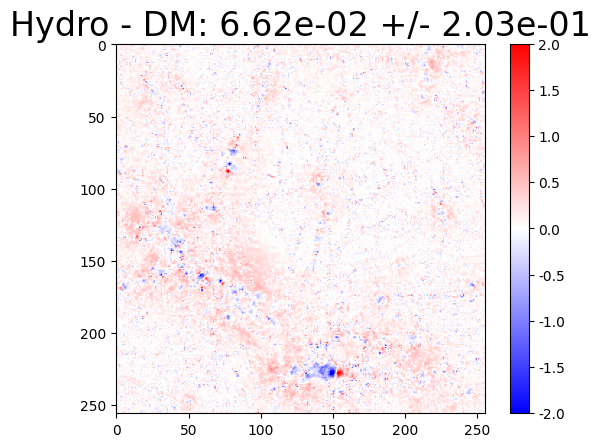

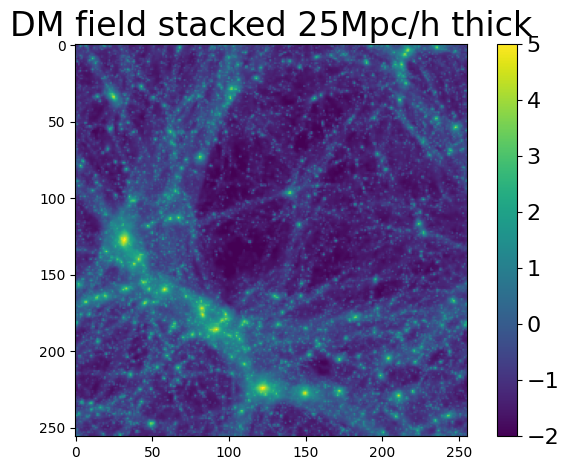

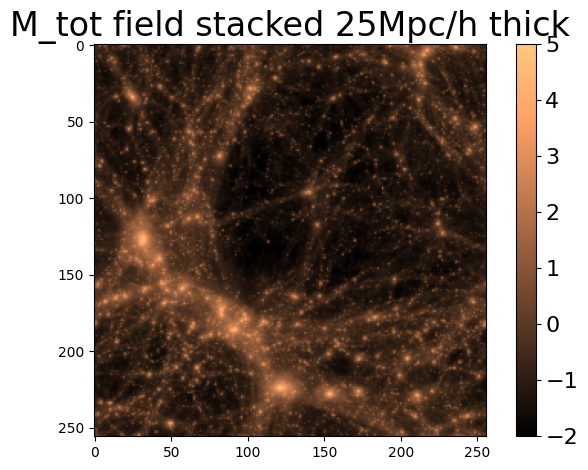

In [7]:
m_delta_log = torch.log(target[0]+1) - torch.log(cond[0]+1)
colors = [(0, 'blue'), (0.5, 'white'), (1, 'red')]
cmap = LinearSegmentedColormap.from_list('custom', colors)
vmin = -2.0
vmax = 2.0

plt.figure()
im = plt.imshow(m_delta_log.squeeze().cpu(),  cmap=cmap, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
plt.title(f'Hydro - DM: {m_delta_log.mean():.2e} +/- {m_delta_log.std():.2e}', fontsize=24)
plt.show()

plt.figure()
plt.imshow(torch.log(cond[0].squeeze().cpu()+1), cmap='viridis', vmin=-2, vmax=5)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=16)
plt.title('DM field stacked 25Mpc/h thick', fontsize=24)
plt.tight_layout()
plt.show()


plt.figure()
plt.imshow(torch.log(target[0].squeeze().cpu()+1), cmap='copper', vmin=-2, vmax=5)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=16)
plt.title('M_tot field stacked 25Mpc/h thick', fontsize=24)
plt.tight_layout()
plt.show()


In [6]:
cond.shape

torch.Size([50, 1, 256, 256])

# Test window function in fourier space

In [8]:

L = 25. #Mpc/c
H = 256
W = 256
fourier_upweight_range = [6,20]
low = fourier_upweight_range[0]
high = fourier_upweight_range[1]

kx = torch.fft.fftfreq(H, d=1. / (H * 2 * np.pi / L))
ky = torch.fft.fftfreq(W, d=1. / (W * 2 * np.pi / L))
kx, ky = torch.meshgrid(kx, ky, indexing="ij") #[256, 256],[256, 256]
k = torch.sqrt(kx**2 + ky**2) 

center = (low + high) / 2  # Center frequency
sigma = (high - low) / 2   # Standard deviation (controls the width of the Gaussian)

order = 2 
low_pass = 1 / (1 + (k / high)**(2 * order))
high_pass = 1 / (1 + (low / k)**(2 * order))

weight_mask =  torch.zeros_like(k)
weight_mask[(k >= fourier_upweight_range[0]) & (k <= fourier_upweight_range[1])] = 1

weight_mask_smooth = weight_mask * (0.5 * (1 - np.cos(2 * np.pi * (k - fourier_upweight_range[0]) / (fourier_upweight_range[1] - fourier_upweight_range[0]))))
weight_mask_gaussian = np.exp(-((k - center)**2) / (2 * sigma**2))
weight_mask_butterworth = high_pass*low_pass +1e-3

LDL_filter =  np.exp(-(fourier_upweight_range[1]/k)**2)*np.exp(-(k/fourier_upweight_range[0])**2)*k**3 #+1

/tmp/ipykernel_1096580/852995749.py:23: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  weight_mask_smooth = weight_mask * (0.5 * (1 - np.cos(2 * np.pi * (k - fourier_upweight_range[0]) / (fourier_upweight_range[1] - fourier_upweight_range[0]))))
/tmp/ipykernel_1096580/852995749.py:24: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  weight_mask_gaussian = np.exp(-((k - center)**2) / (2 * sigma**2))
/tmp/ipykernel_1096580/852995749.py:27: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  LDL_filter =  np.exp(-(fourier_upweight_range[1]/k)**2)*np.exp(-(k/fourier_upweight_range[0])**2)*k**3 #+1


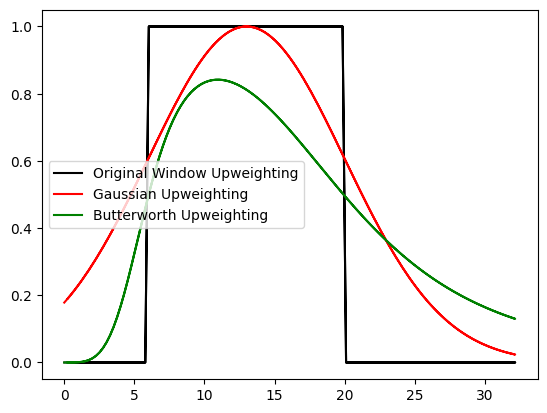

In [9]:
plt.plot(k[0,:],weight_mask[0,:],'k',label = 'Original Window Upweighting')
#plt.plot(k[0,:],weight_mask_smooth[0,:], 'y',label = 'Gaussian Upweighting')
plt.plot(k[0,:],weight_mask_gaussian[0,:], 'r',label = 'Gaussian Upweighting')
plt.plot(k[0,:],weight_mask_butterworth[0,:], 'g',label = 'Butterworth Upweighting')
#plt.plot(k,LDL_filter, 'b')
plt.legend()
plt.show()

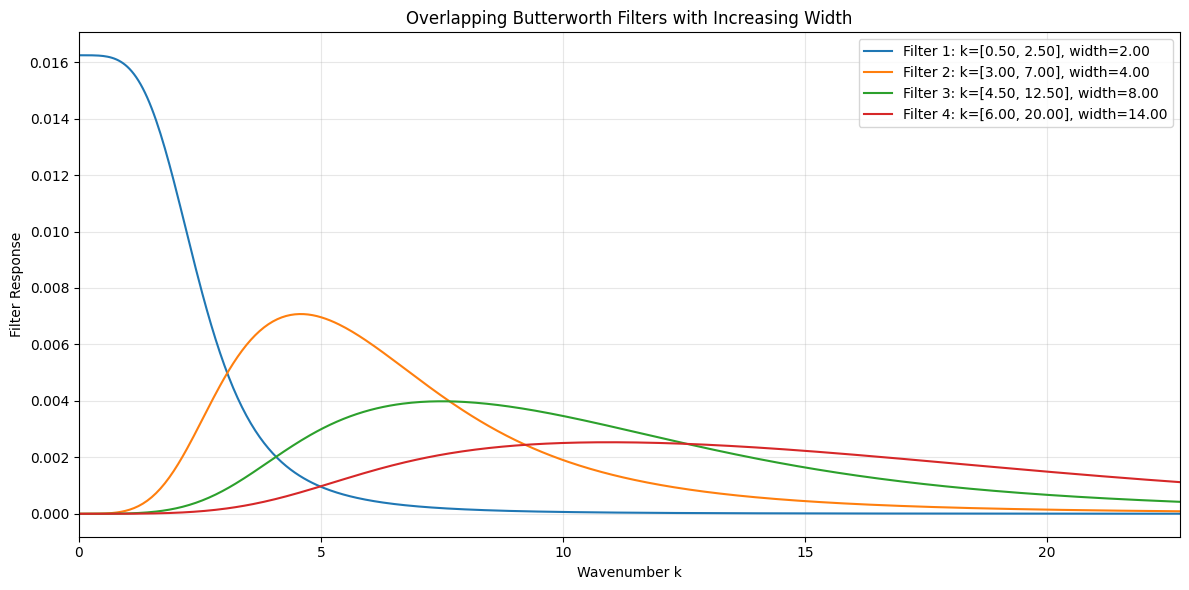

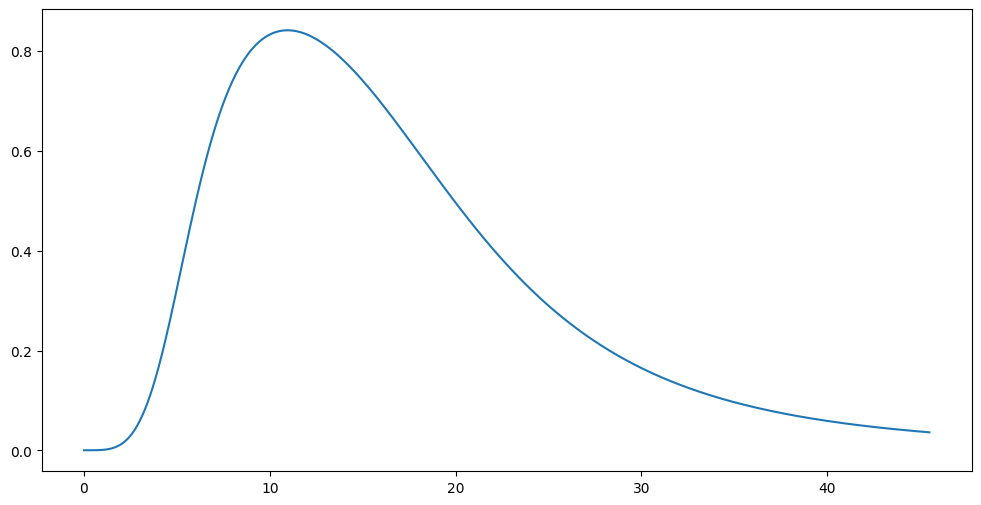

Filter Information:
Filter 1: k range=[0.50, 2.50], center=1.50, width=2.00
Filter 2: k range=[3.00, 7.00], center=5.00, width=4.00
Filter 3: k range=[4.50, 12.50], center=8.50, width=8.00
Filter 4: k range=[6.00, 20.00], center=13.00, width=16.00


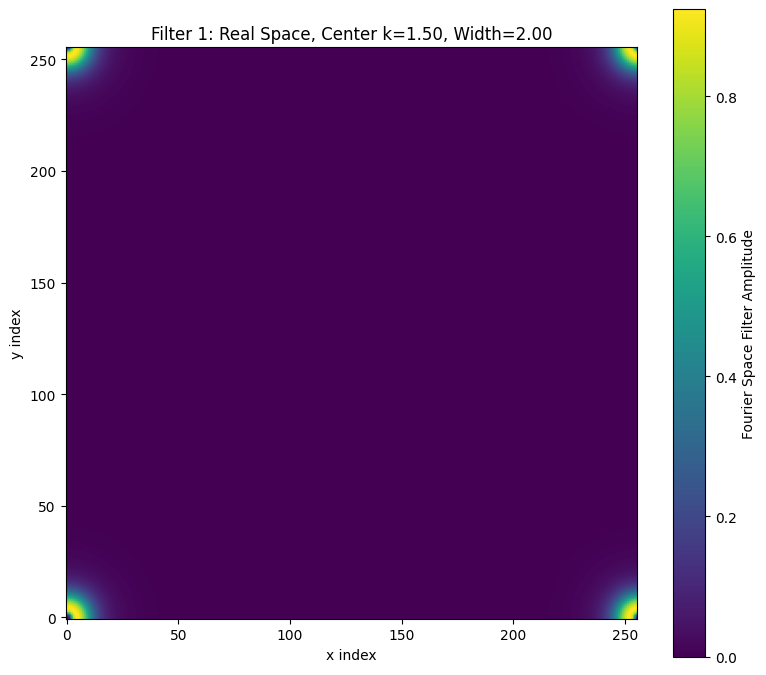

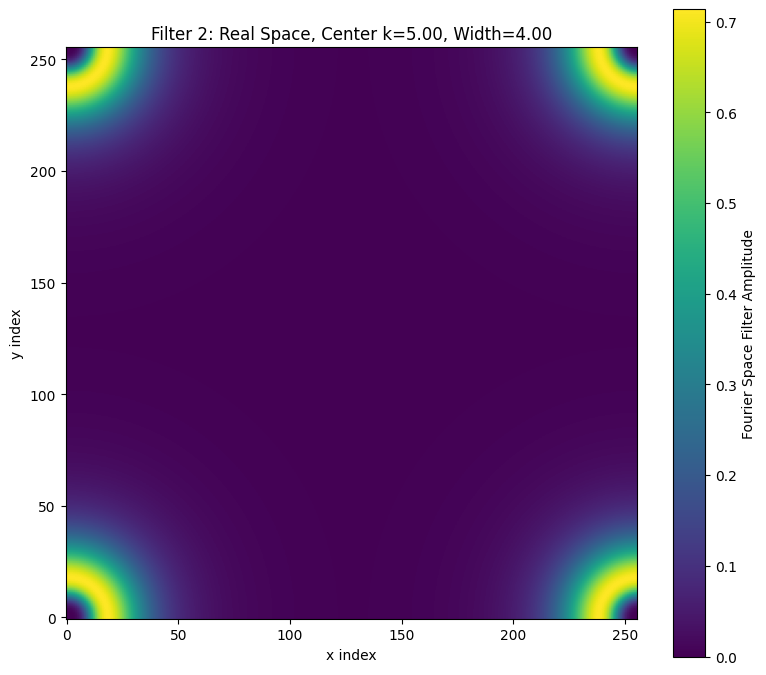

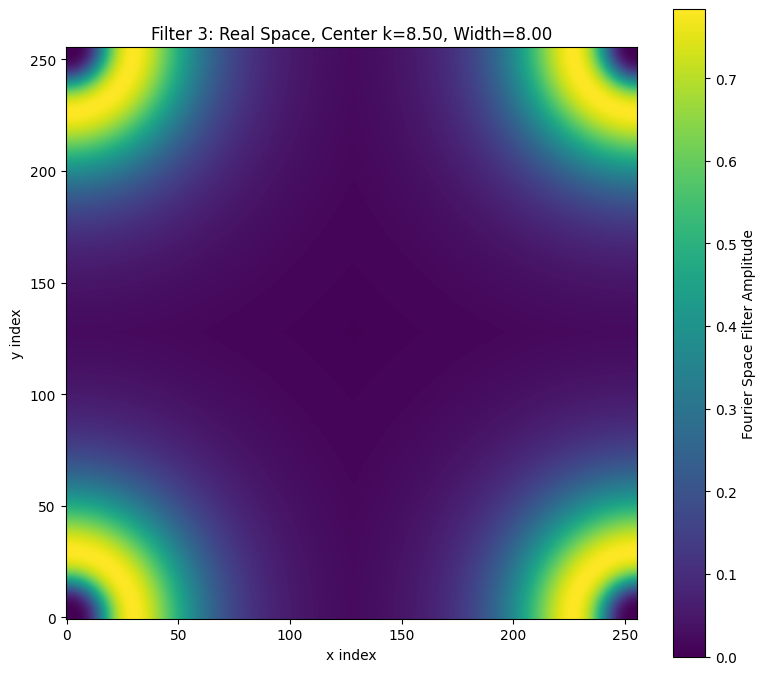

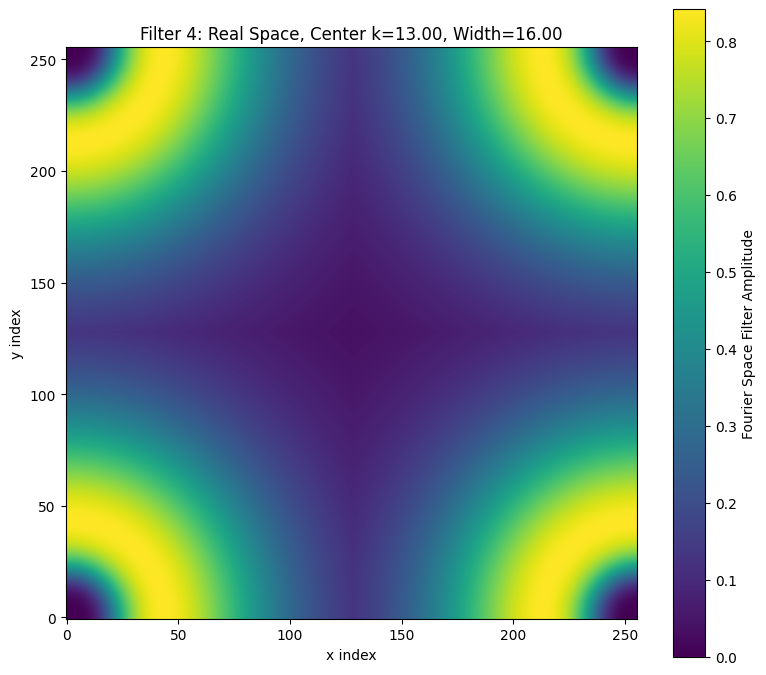

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Initial parameters
L = 25.  # Mpc/h
H = 256
W = 256
order = 2

# Compute frequency grids
kx = torch.fft.fftfreq(H, d=1. / (H * 2 * np.pi / L))
ky = torch.fft.fftfreq(W, d=1. / (W * 2 * np.pi / L))
kx, ky = torch.meshgrid(kx, ky, indexing="ij")  # [256, 256],[256, 256]
k = torch.sqrt(kx**2 + ky**2)

# Creating multiple overlapping Butterworth filters
# Initial range
initial_low = 6
initial_high = 20

# Define number of filters to generate
num_filters = 4

# List to store all filter masks
butterworth_filters = []

for i in range(num_filters):
    # Calculate width for this filter (increasing by factor of 2 each time)
    width = 2 * (2**i)
    
    # Calculate center for this filter (moving to larger k values)
    if i == 0:
        # First filter uses the initial range
        low = 0.5
        high = low + 2**(i+1)
    else:
        low =initial_low*(i+1)/num_filters
        high = low + 2**(i+1)
        if high > initial_high:
            high = initial_high    
    # Create Butterworth filter
    low_pass = 1 / (1 + (k / high)**(2 * order))
    high_pass = 1 / (1 + (low / k)**(2 * order))
    weight_mask = low_pass * high_pass  # Band-pass filter
    
    # Store filter information
    filter_info = {
        'low': low,
        'high': high,
        'width': width,
        'weight_mask': weight_mask,
        'center': (low + high) / 2
    }
    
    butterworth_filters.append(filter_info)

# Plot the filter response along a radial line
max_k = torch.max(k).item()
k_values = torch.linspace(0, max_k, 1000)

plt.figure(figsize=(12, 6))
filter_overlap = []
# Plot each filter response
for i, filt in enumerate(butterworth_filters):
    low, high = filt['low'], filt['high']
    
    # Calculate filter response for 1D k values
    low_pass_1d = 1 / (1 + (k_values / high)**(2 * order))
    high_pass_1d = 1 / (1 + (low / k_values)**(2 * order))
    # Handle division by zero warning in high_pass_1d
    high_pass_1d[k_values == 0] = 0
    if i == 0:
        response = low_pass_1d + 1e-4
    else:
        response = low_pass_1d * high_pass_1d + 1e-4
    '''
    max_val = torch.max(response)
    if max_val > 0:  # Avoid division by zero
        weight_mask = weight_mask / max_val
    '''
    epsilon = 1e-10  # Small value to avoid division by zero

    weight_mask = response /torch.clamp(sum(response), min=epsilon) 
    filter_overlap.append(weight_mask)

    plt.plot(k_values, weight_mask, 
             label=f"Filter {i+1}: k=[{low:.2f}, {high:.2f}], width={high-low:.2f}")

plt.title("Overlapping Butterworth Filters with Increasing Width")
plt.xlabel("Wavenumber k")
plt.ylabel("Filter Response")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xlim(0, max_k/2)  # Limit x-axis to see the filters more clearly
plt.tight_layout()

plt.figure(figsize=(12, 6))
plt.plot(k_values, response, label=f"collective filter")
plt.show()

# Display filter information
print("Filter Information:")
for i, filt in enumerate(butterworth_filters):
    print(f"Filter {i+1}: k range=[{filt['low']:.2f}, {filt['high']:.2f}], "
          f"center={filt['center']:.2f}, width={filt['width']:.2f}")

# Function to visualize a filter in 2D real space
def plot_filter_2d(filter_mask, title):
    # Perform inverse Fourier transform to get real space representation
    # First, shift the filter back to standard FFT layout
    
    # Perform inverse Fourier transform 
    real_space_filter = filter_mask.real
    
    plt.figure(figsize=(8, 7))
    plt.imshow(real_space_filter.numpy(), cmap='viridis', origin='lower')
    plt.colorbar(label='Fourier Space Filter Amplitude')
    plt.title(title)

    plt.xlabel('x index')
    plt.ylabel('y index')
    plt.tight_layout()

# Plot each filter in 2D real space
for i, filt in enumerate(butterworth_filters):
    plot_filter_2d(filt['weight_mask'], 
                   f"Filter {i+1}: Real Space, Center k={filt['center']:.2f}, Width={filt['width']:.2f}")



Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.01 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds

Computing power spectra of the fields...
Time FFTS = 0.00
Time loop = 0.00
Time taken = 0.00 seconds


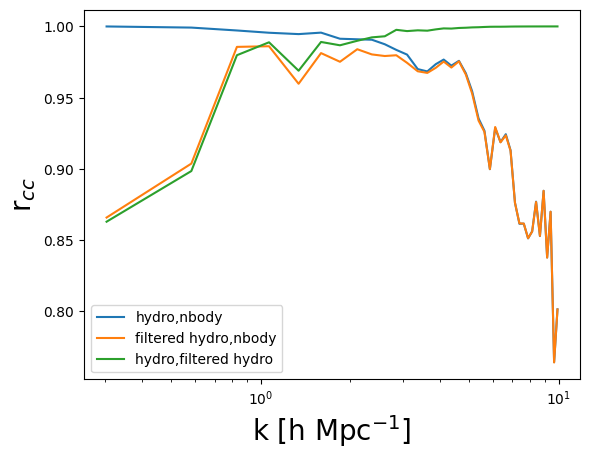

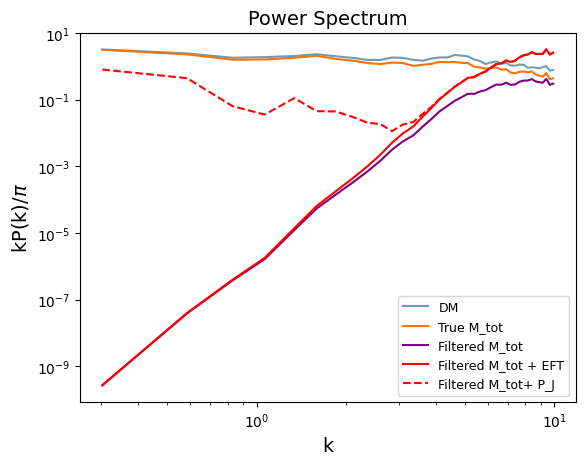

In [7]:
# Overdensity -- same Pk as physical units inverse transformation !!

grid    = 256     #the map will have grid^2 pixels
BoxSize = 25 #Mpc/h
MAS     = 'None'  #MAS used to create the image; 'NGP', 'CIC', 'TSC', 'PCS' o 'None'
threads = 1       #number of openmp threads
axis = 0
verbose = False

sims = [0]

for sim in sims:
    filtered_x = np.real(ifft2(fft2(target[sim].cpu().numpy().reshape([256,256]))*filter_overlap[3].numpy()))
    #filtered_x = filtered_x/filtered_x.mean()-1
    
    Pkcc = PKL.XPk_plane((target[sim]).detach().numpy().reshape([256,256]),(cond[sim]).detach().numpy().reshape([256,256]),  BoxSize, MAS,MAS, threads=1) 
    kcc_true   = Pkcc.k
    Pk0_X_true = Pkcc.r
    plt.figure()
    plt.plot(kcc_true[kcc_true <= 10], Pk0_X_true[kcc_true <= 10],label = f'hydro,nbody')
    Pkcc_ = PKL.XPk_plane(filtered_x.reshape([256,256]),(cond[sim]).detach().numpy().reshape([256,256]),  BoxSize, MAS,MAS, threads=1) 
    kcc_true_   = Pkcc_.k
    Pk0_X_true_ = Pkcc_.r
    plt.plot(kcc_true_[kcc_true <= 10], Pk0_X_true_[kcc_true <= 10],label = f'filtered hydro,nbody')
    Pkcc = PKL.XPk_plane((target[sim]).detach().numpy().reshape([256,256]),filtered_x.reshape([256,256]),  BoxSize, MAS,MAS, threads=1) 
    kcc_true   = Pkcc.k
    Pk0_X_true = Pkcc.r
    plt.plot(kcc_true[kcc_true <= 10], Pk0_X_true[kcc_true <= 10],label = f'hydro,filtered hydro')
    plt.xscale('log')
    plt.xlabel(r'k [h Mpc$^{-1}$]', fontsize=20)
    plt.ylabel(r'r$_{cc}$', fontsize=20)
    plt.legend()
    plt.show()

    ## compute_pk == PKL!!
    plt.figure()
    k, P_con = compute_pk(cond[sim].cpu().numpy().reshape([1,1,256,256]))
    plt.loglog(k, k*P_con/np.pi, label="DM", color='#709bb5')
    k, P_x = compute_pk(target[sim].cpu().numpy().reshape([1,1,256,256]))
    plt.loglog(k, k*P_x/np.pi, label="True M_tot", color='#F97306')
    k, P_x_filter = compute_pk(filtered_x.reshape([1,1,256,256]))
    plt.loglog(k, k*P_x_filter/np.pi, label="Filtered M_tot", color='purple')
    kcc_idx = np.array([np.argmin(np.abs(kcc_true - ki)) for ki in k])
    #P_x_filter_eft = P_x_filter +2/(9*0.45037521)*k**2* P_x_filter
    eps =np.random.uniform()
    P_x_filter_eft = P_x_filter + eps*k**2* P_x_filter
    plt.loglog(k, k*P_x_filter_eft/np.pi, label="Filtered M_tot + EFT", color='red')
    P_x_filter_eft = P_x_filter_eft+P_x*(1-Pk0_X_true[kcc_idx]**2)
    plt.loglog(k, k*P_x_filter_eft/np.pi, '--', label="Filtered M_tot+ P_J", color='red')

   
    Pk2D_hydro = PKL.Pk_plane(target[sim].detach().numpy().reshape([256,256]), BoxSize, MAS, threads, verbose)
    Pk2D_Nbody = PKL.Pk_plane(cond[sim].detach().numpy().reshape([256,256]), BoxSize,  MAS, threads, verbose)
    k   = Pk2D_Nbody.k
    P_con   = Pk2D_Nbody.Pk
    #plt.loglog(k[k<10], P_con[k<10], label="DM PKL", color='#709bb5', ls = '--')
    k   = Pk2D_hydro.k
    P_x   = Pk2D_hydro.Pk
    #plt.loglog(k[k<10], P_x[k<10], label="True M_tot PKL", color='#F97306', ls = '--')
    plt.legend(fontsize=9)
    plt.xlabel('k',fontsize=14)
    plt.ylabel('kP(k)/$\pi$',fontsize=14)
    plt.title("Power Spectrum", fontsize=14)
    

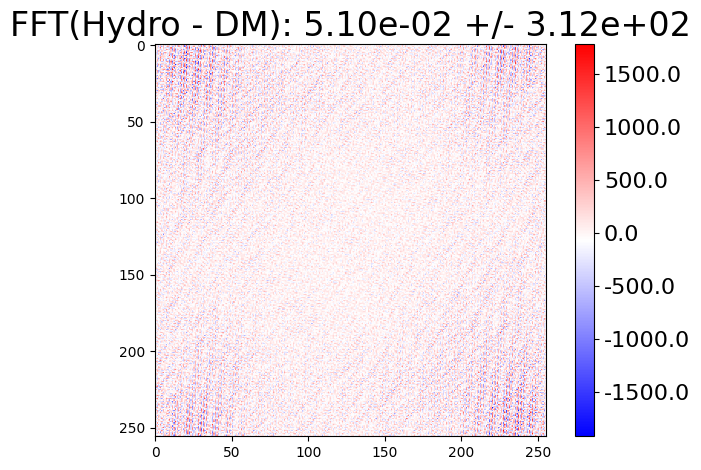

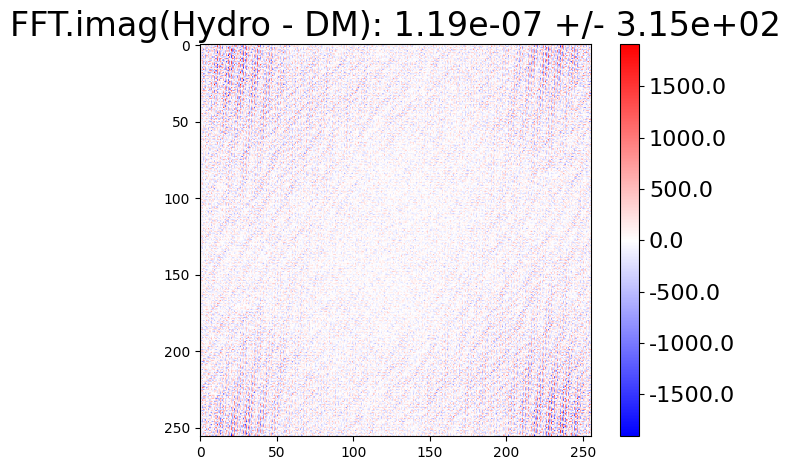

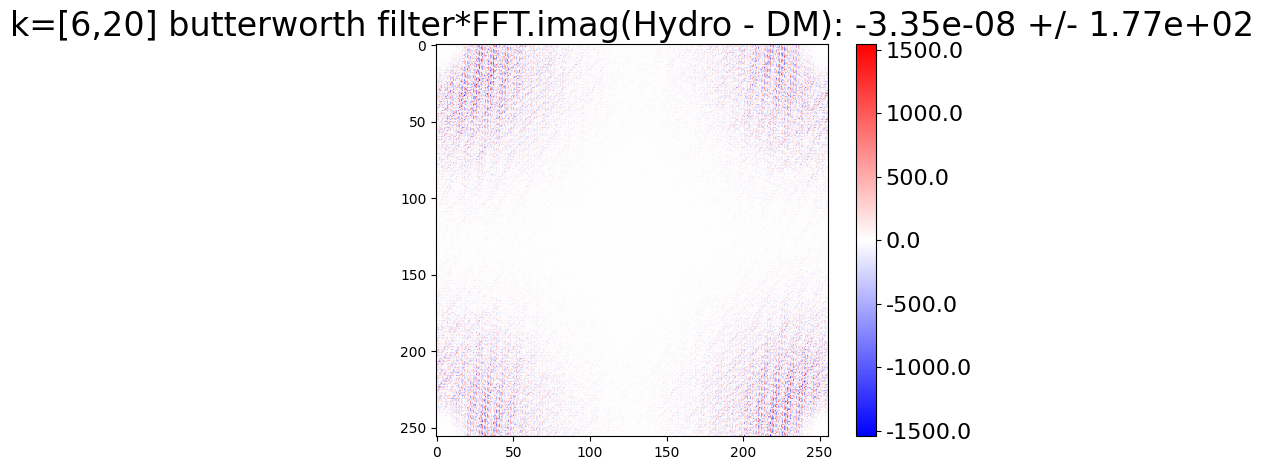

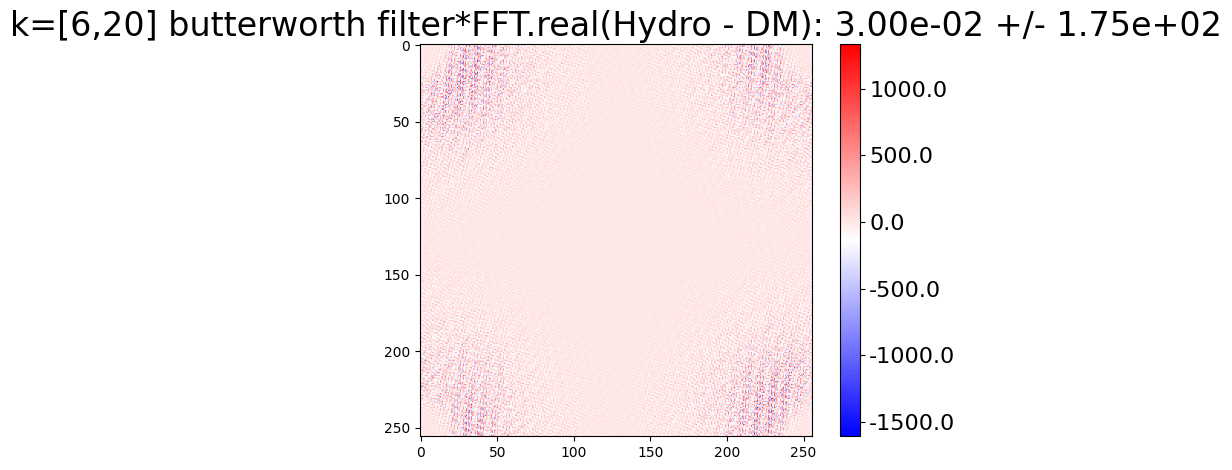

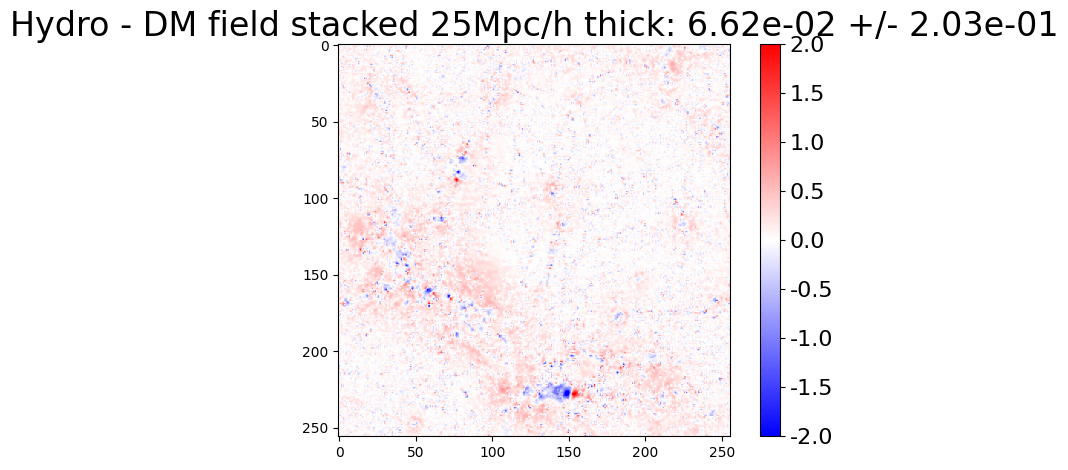

/tmp/ipykernel_1096580/125082252.py:60: RuntimeWarning: invalid value encountered in log
  diff_trans = np.log(np.real(ifft2(fft2(hydro_map)*weight_mask_butterworth.numpy()))/10+1)  -  np.log(NBody_map+1)


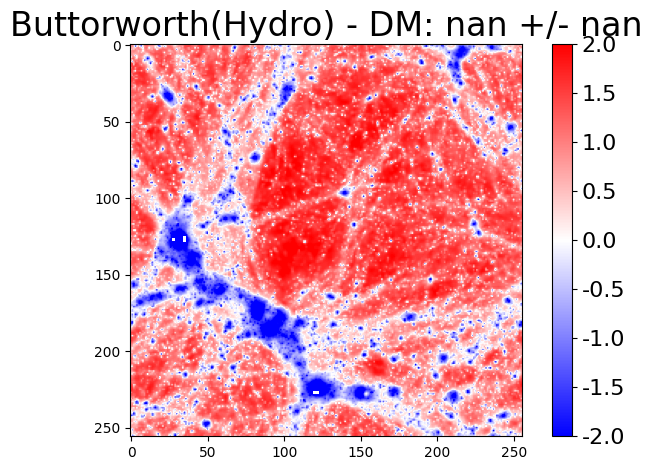

/tmp/ipykernel_1096580/125082252.py:69: RuntimeWarning: invalid value encountered in log
  diff_trans = np.log((5*hydro_map+5*np.real(ifft2(fft2(hydro_map)*weight_mask_butterworth.numpy())))/10+1)  -  np.log(NBody_map+1)


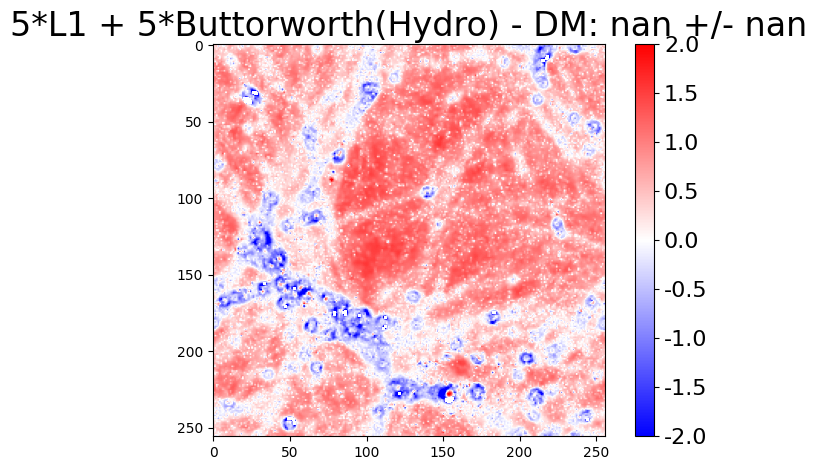

NameError: name 'filter_overlap' is not defined

<Figure size 640x480 with 0 Axes>

In [13]:
## import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.ticker import FormatStrFormatter
colors = [(0, 'blue'), (0.5, 'white'), (1, 'red')]
cmap = LinearSegmentedColormap.from_list('custom', colors)

vmin = -2.0
vmax = 2.0

hydro_map = target[0].squeeze(0).numpy()
NBody_map = cond[0].squeeze(0).numpy()


plt.figure()
fft_trans = np.real(fft2(hydro_map-NBody_map))
im = plt.imshow(fft_trans, cmap=cmap) #, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'FFT(Hydro - DM): {fft_trans.mean():.2e} +/- {fft_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

plt.figure()
fft_trans = np.imag(fft2(hydro_map-NBody_map))
im = plt.imshow(fft_trans, cmap=cmap) #, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'FFT.imag(Hydro - DM): {fft_trans.mean():.2e} +/- {fft_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

plt.figure()
fft_trans = np.imag(fft2(hydro_map-NBody_map)*weight_mask_butterworth.numpy())
im = plt.imshow(fft_trans, cmap=cmap) #, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'k=[6,20] butterworth filter*FFT.imag(Hydro - DM): {fft_trans.mean():.2e} +/- {fft_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

plt.figure()
fft_trans = np.real(fft2(hydro_map-NBody_map)*weight_mask_butterworth.numpy())
im = plt.imshow(fft_trans, cmap=cmap) #, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'k=[6,20] butterworth filter*FFT.real(Hydro - DM): {fft_trans.mean():.2e} +/- {fft_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

diff = np.log(hydro_map+1) - np.log(NBody_map+1)
plt.figure()
im = plt.imshow(diff, cmap=cmap, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'Hydro - DM field stacked 25Mpc/h thick: {diff.mean():.2e} +/- {diff.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

plt.figure()
diff_trans = np.log(np.real(ifft2(fft2(hydro_map)*weight_mask_butterworth.numpy()))/10+1)  -  np.log(NBody_map+1)
im = plt.imshow(diff_trans, cmap=cmap, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'Buttorworth(Hydro) - DM: {diff_trans.mean():.2e} +/- {diff_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

plt.figure()
diff_trans = np.log((5*hydro_map+5*np.real(ifft2(fft2(hydro_map)*weight_mask_butterworth.numpy())))/10+1)  -  np.log(NBody_map+1)
im = plt.imshow(diff_trans, cmap=cmap, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'5*L1 + 5*Buttorworth(Hydro) - DM: {diff_trans.mean():.2e} +/- {diff_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

plt.figure()
diff_trans = np.log(np.real(ifft2(fft2(hydro_map)*filter_overlap[0].numpy()))+1) -  np.log(NBody_map+1)
im = plt.imshow(diff_trans, cmap=cmap, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'moving(Hydro) - DM: {diff_trans.mean():.2e} +/- {diff_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

plt.figure()
diff_trans = np.log(np.real(ifft2(fft2(hydro_map)*filter_overlap[3].numpy()))+1) -  np.log(NBody_map+1)
im = plt.imshow(diff_trans, cmap=cmap, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'moving(Hydro) - DM: {diff_trans.mean():.2e} +/- {diff_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

plt.figure()
filteredx = np.real(ifft2(fft2(hydro_map)*filter_overlap[3].numpy()))
eps =np.random.uniform()
filteredx_stoch = np.real(ifft2(fft2(filteredx) * np.where(filter_overlap[3].numpy() != 0, 1 / filter_overlap[3].numpy(), 0)))
diff_trans = np.log(filteredx +hydro_map - filteredx_stoch +1)  -  np.log(NBody_map+1) 
im = plt.imshow(diff_trans, cmap=cmap, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'moving(Hydro) - DM: {diff_trans.mean():.2e} +/- {diff_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

plt.figure()
filteredx_stoch_rcc = applyTF_2D(hydro_map, kcc_true , (1- Pk0_X_true**2), 256,25)
diff_trans = np.log(filteredx+1 + filteredx_stoch_rcc)-  np.log(NBody_map+1) 
im = plt.imshow(diff_trans, cmap=cmap, vmin=vmin, vmax=vmax)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.1f'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'moving(Hydro) - DM: {diff_trans.mean():.2e} +/- {diff_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

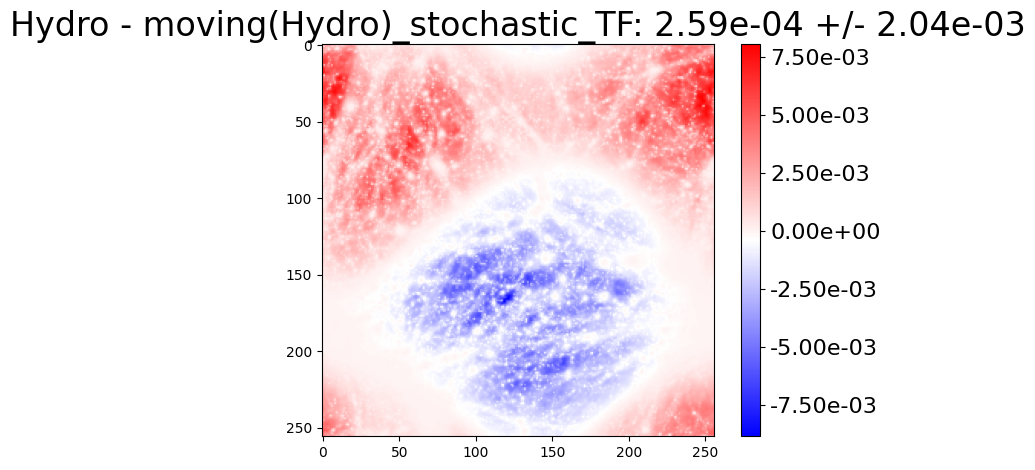

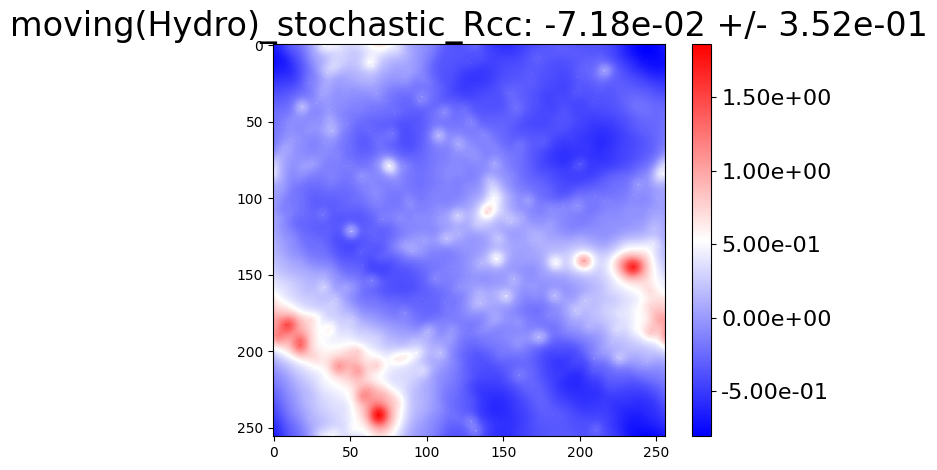

In [30]:
plt.figure()
diff_trans = np.log(hydro_map+1)  - np.log(filteredx_stoch +1) 
im = plt.imshow(diff_trans, cmap=cmap)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.2e'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'Hydro - moving(Hydro)_stochastic_TF: {diff_trans.mean():.2e} +/- {diff_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

plt.figure()
diff_trans = np.log(1 + filteredx_stoch_rcc) 
im = plt.imshow(diff_trans, cmap=cmap)
cbar = plt.colorbar(im, format=FormatStrFormatter('%.2e'))
cbar.ax.tick_params(labelsize=16)
plt.title(f'moving(Hydro)_stochastic_Rcc: {diff_trans.mean():.2e} +/- {diff_trans.std():.2e}', fontsize=24)
plt.tight_layout()
plt.show()

# Stack for 25 Mpc thickness

Execution time for one sim: 0.0494 seconds


/tmp/ipykernel_1527102/1084170090.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.log(Nbody_map.squeeze().cpu()), cmap='viridis', vmin=-2, vmax=5)


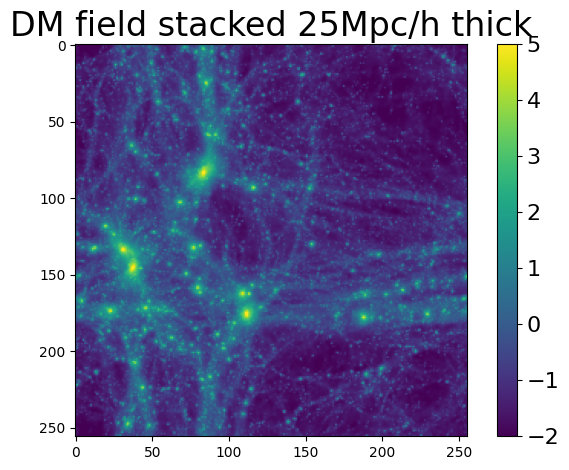

In [4]:
import time
start_time = time.time()
Nbody_map = Flip(2)(Tensor(NBody_map))
end_time = time.time()
# Calculate and print the elapsed time
execution_time = end_time - start_time
print(f"Execution time for one sim: {execution_time:.4f} seconds")

plt.figure()
plt.imshow(np.log(Nbody_map.squeeze().cpu()), cmap='viridis', vmin=-2, vmax=5)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=16)
plt.title('DM field stacked 25Mpc/h thick', fontsize=24)
plt.tight_layout()
plt.show()

In [5]:
print(Tensor(np.asarray(NBody_grid)).unsqueeze(0).shape)

torch.Size([1, 256, 256, 256])


In [2]:
cropsize = 256
batch_size = 12
num_workers = 8
   
dataset = 'Astrid'
learning_rate = 1e-3 #1e-4

cpu_before = psutil.cpu_percent(interval=None)
    
    # Start time measurement
start_time = time.time()
    
dm_TF = get_astro_data_2D_from_3D(
        dataset,
        num_workers=num_workers,
        resize=cropsize,
        batch_size=batch_size,
        map_per_sim=3)
    
    # Record final CPU usage
cpu_after = psutil.cpu_percent(interval=None)
elapsed_time = time.time() - start_time
    
print(f"CPU usage before execution: {cpu_before}%")
print(f"CPU usage after execution: {cpu_after}%")
print(f"Function execution time: {elapsed_time:.2f} seconds")

CPU usage before execution: 0.2%
CPU usage after execution: 1.7%
Function execution time: 149.68 seconds


In [ ]:
one_batch = next(iter(dm_TF.test_dataloader()))
conditioning, params, target = one_batch
print(conditioning.shape, params.shape,target.shape)
print(conditioning.device, params.device,target.device)

In [ ]:
start_time = time.time()

train_dir = '/pscratch/sd/l/lindajin/CAMELS/'
map_per_sim = 3
mass_mtot = np.load(train_dir+
                    f'Grids_Mtot_Astrid_LH_256_z=0.0.npy'
                )        
mass_cdm = np.load(train_dir+
                    f'Grids_Mcdm_Astrid_LH_256_z=0.0.npy'
                )
params = np.loadtxt(train_dir+
                    f'params_LH_Astrid.txt'
                )

maps_params = np.empty((map_per_sim*len(mass_mtot),params.shape[1]))
mass_mtot_2D = Tensor(np.concatenate((mass_mtot.mean(axis = 1),mass_mtot.mean(axis = 2),mass_mtot.mean(axis = 3)),axis=0)).unsqueeze(1)
mass_cdm_2D = Tensor(np.concatenate((mass_cdm.mean(axis = 1),mass_cdm.mean(axis = 2),mass_cdm.mean(axis = 3)), axis=0)).unsqueeze(1)
for i in range(len(mass_mtot)):
    maps_params[i]= params[i//map_per_sim]

maps_params = Tensor(np.asarray(maps_params))

end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time for one sim: {execution_time:.4f} seconds")

# Stack for 100 Mpc thickness

Execution time for one sim: 0.1289 seconds


/tmp/ipykernel_1978659/1885226446.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.log(Nbody_map[0].squeeze().cpu()), cmap='viridis', vmin=-2, vmax=5)


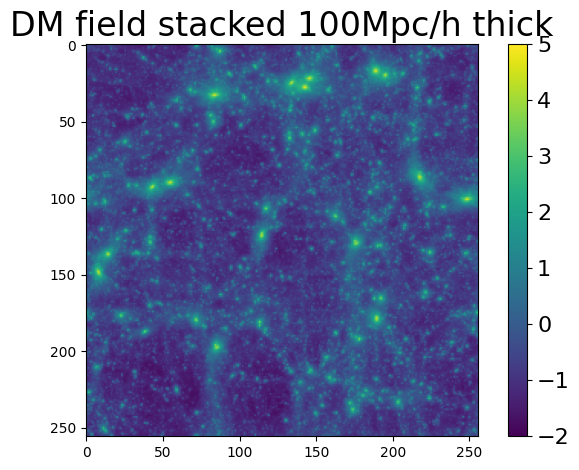

/tmp/ipykernel_1978659/1885226446.py:17: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.log(Nbody_map[2].squeeze().cpu()), cmap='viridis', vmin=-2, vmax=5)


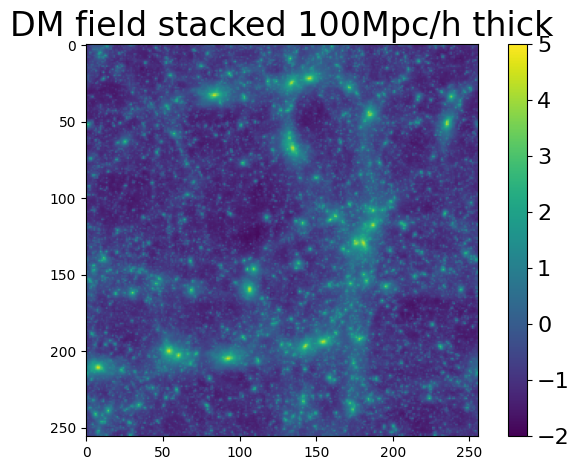

/tmp/ipykernel_1978659/1885226446.py:24: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.log(Nbody_map[3].squeeze().cpu()), cmap='viridis', vmin=-2, vmax=5)


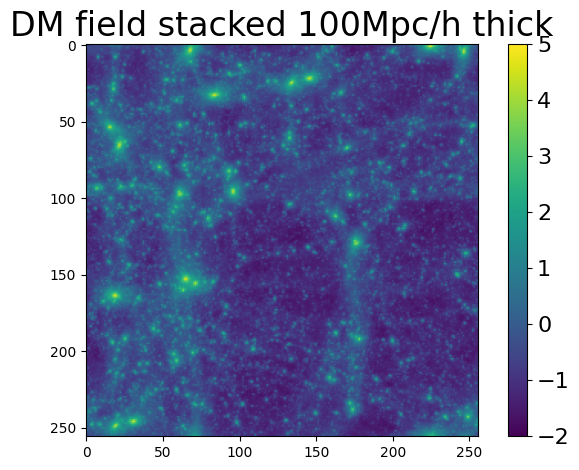

/tmp/ipykernel_1978659/1885226446.py:31: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.imshow(np.log(Nbody_map[4].squeeze().cpu()), cmap='viridis', vmin=-2, vmax=5)


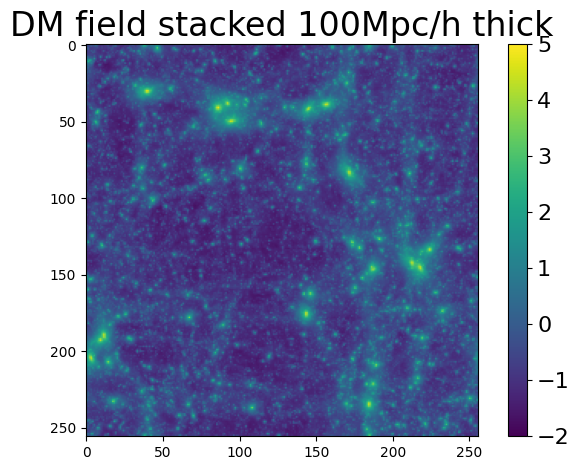

In [6]:
start_time = time.time()
Nbody_map = Stack(5)(Tensor(np.asarray(NBody_grid)).unsqueeze(0))
end_time = time.time()

# Calculate and print the elapsed time
execution_time = end_time - start_time
print(f"Execution time for one sim: {execution_time:.4f} seconds")

plt.figure()
plt.imshow(np.log(Nbody_map[0].squeeze().cpu()), cmap='viridis', vmin=-2, vmax=5)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=16)
plt.title('DM field stacked 100Mpc/h thick', fontsize=24)
plt.tight_layout()
plt.show()
plt.figure()
plt.imshow(np.log(Nbody_map[2].squeeze().cpu()), cmap='viridis', vmin=-2, vmax=5)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=16)
plt.title('DM field stacked 100Mpc/h thick', fontsize=24)
plt.tight_layout()
plt.show()
plt.figure()
plt.imshow(np.log(Nbody_map[3].squeeze().cpu()), cmap='viridis', vmin=-2, vmax=5)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=16)
plt.title('DM field stacked 100Mpc/h thick', fontsize=24)
plt.tight_layout()
plt.show()
plt.figure()
plt.imshow(np.log(Nbody_map[4].squeeze().cpu()), cmap='viridis', vmin=-2, vmax=5)
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=16)
plt.title('DM field stacked 100Mpc/h thick', fontsize=24)
plt.tight_layout()
plt.show()

In [32]:
print(np.all(NBody_grid > 0))
for m in Nbody_map:
    print(torch.std(m))

True
tensor(2.3545)
tensor(2.3600)
tensor(2.3372)
tensor(2.3666)
tensor(2.3995)


In [3]:
import importlib
import camel_dataloader

importlib.reload(camel_dataloader) 
from camel_dataloader import Stack, Flip, get_astro_data_2D_from_3D

In [57]:
mass_cdm = Tensor(np.asarray([NBody_grid,NBody_grid])).unsqueeze(1) #torch.Size([1, 1, 256, 256, 256])
mass_cdm_2D = [] #torch.Size([1*5, 1, 256, 256, 256])
for i, img in enumerate(mass_cdm):
    print(img.shape)
    maps = Stack(5)(img)
    print(maps.shape)
    mass_cdm_2D.append(maps)
    
mass_cdm_2D = torch.cat(mass_cdm_2D, dim=0) 
print(mass_cdm_2D.shape)

torch.Size([1, 256, 256, 256])
for flip torch.Size([256, 256])
for rotate torch.Size([256, 256])
for flip torch.Size([256, 256])
for flip torch.Size([256, 256])
for rotate torch.Size([256, 256])
for rotate torch.Size([256, 256])
torch.Size([5, 1, 256, 256])
torch.Size([1, 256, 256, 256])
for rotate torch.Size([256, 256])
for flip torch.Size([256, 256])
for flip torch.Size([256, 256])
for flip torch.Size([256, 256])
for rotate torch.Size([256, 256])
for flip torch.Size([256, 256])
for flip torch.Size([256, 256])
for rotate torch.Size([256, 256])
torch.Size([5, 1, 256, 256])
torch.Size([10, 1, 256, 256])


In [12]:

start_time = time.time()

train_dir = '/pscratch/sd/l/lindajin/CAMELS/'
map_per_sim = 15
mass_mtot = np.load(train_dir+
                    f'Grids_Mtot_Astrid_LH_256_z=0.0.npy'
                )        
mass_cdm = np.load(train_dir+
                    f'Grids_Mcdm_Astrid_LH_256_z=0.0.npy'
                )
params = np.loadtxt(train_dir+
                    f'params_LH_Astrid.txt'
                )

maps_params = np.empty((map_per_sim*len(mass_mtot),params.shape[1]))
mass_mtot_2D = []
mass_cdm_2D = [] #torch.Size([1*5, 1, 256, 256, 256])
for i in range(len(mass_mtot)):
    maps_params[i]= params[i//map_per_sim]
    mass_mtot_2D.append(Stack(map_per_sim)(Tensor(mass_mtot).unsqueeze(1)[i]))
    mass_cdm_2D.append(Stack(map_per_sim)(Tensor(mass_cdm).unsqueeze(1)[i]))

maps_params = Tensor(np.asarray(maps_params))
mass_cdm_2D = torch.cat(mass_cdm_2D, dim=0) 
mass_mtot_2D = torch.cat(mass_mtot_2D, dim=0) 

end_time = time.time()
execution_time = end_time - start_time
print(f"Execution time for one sim: {execution_time:.4f} seconds")

Execution time for one sim: 221.4316 seconds


In [13]:
print(mass_mtot_2D.shape, mass_cdm_2D.shape, maps_params.shape)
# Convert PyTorch tensors to NumPy arrays
maps_params_np = maps_params.cpu().numpy()  # Ensure tensor is on the CPU before conversion
mass_cdm_2D_np = mass_cdm_2D.cpu().numpy()
mass_mtot_2D_np = mass_mtot_2D.cpu().numpy()

np.save(train_dir+f"Maps_{map_per_sim}_params_LH_Astrid.npy", maps_params_np)
np.save(train_dir+f"Maps_{map_per_sim}_thick=100_Mcdm_Astrid_LH_256_z=0.0.npy", mass_cdm_2D_np)
np.save(train_dir+f"Maps_{map_per_sim}_thick=100_Mtot_Astrid_LH_256_z=0.0.npy", mass_mtot_2D_np)

print("Files saved successfully!")

torch.Size([15000, 1, 256, 256]) torch.Size([15000, 1, 256, 256]) torch.Size([15000, 6])
Files saved successfully!


In [16]:
cropsize = 256
batch_size = 12
num_workers = 8
   
dataset = 'Astrid'
learning_rate = 1e-3 #1e-4

cpu_before = psutil.cpu_percent(interval=None)
    
    # Start time measurement
start_time = time.time()
    
dm_TF = get_astro_data_2D_from_3D(
        dataset,
        num_workers=num_workers,
        resize=cropsize,
        batch_size=batch_size)
    
    # Record final CPU usage
cpu_after = psutil.cpu_percent(interval=None)
elapsed_time = time.time() - start_time
    
print(f"CPU usage before execution: {cpu_before}%")
print(f"CPU usage after execution: {cpu_after}%")
print(f"Function execution time: {elapsed_time:.2f} seconds")

CPU usage before execution: 3.6%
CPU usage after execution: 10.8%
Function execution time: 170.44 seconds


In [ ]:
one_batch = next(iter(dm_TF.test_dataloader()))
conditioning, params, target = one_batch
print(conditioning.shape, params.shape,target.shape)
print(conditioning.device, params.device,target.device)